In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [2]:
import pandas as pd

df = pd.read_csv("/content/yield_df.csv")

# Filter dataset to African countries only, to align with our mission focus
african_countries = [
    'Algeria','Angola','Botswana','Burkina Faso','Burundi','Cameroon',
    'Central African Republic','Egypt','Eritrea','Ghana','Guinea','Kenya',
    'Lesotho','Libya','Madagascar','Malawi','Mali','Mauritania','Mauritius',
    'Morocco','Mozambique','Namibia','Niger','Rwanda','Senegal','South Africa',
    'Sudan','Tunisia','Uganda','Zambia','Zimbabwe'
]

df = df[df['Area'].isin(african_countries)]
print("Rows after filtering to Africa:", df.shape[0])
print("Unique countries:", df['Area'].nunique())
df.head()
df.head()

Rows after filtering to Africa: 5523
Unique countries: 31


,Unnamed: 0,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
99,99,Algeria,Maize,1990,16500,89.0,1828.92,17.48
100,100,Algeria,Potatoes,1990,78936,89.0,1828.92,17.48
101,101,Algeria,"Rice, paddy",1990,28000,89.0,1828.92,17.48
102,102,Algeria,Sorghum,1990,16571,89.0,1828.92,17.48
103,103,Algeria,Wheat,1990,6315,89.0,1828.92,17.48


In [3]:
print(df.shape)

(5523, 8)


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5523 entries, 99 to 28241
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Unnamed: 0                     5523 non-null   int64  
 1   Area                           5523 non-null   object 
 2   Item                           5523 non-null   object 
 3   Year                           5523 non-null   int64  
 4   hg/ha_yield                    5523 non-null   int64  
 5   average_rain_fall_mm_per_year  5523 non-null   float64
 6   pesticides_tonnes              5523 non-null   float64
 7   avg_temp                       5523 non-null   float64
dtypes: float64(3), int64(3), object(2)
memory usage: 388.3+ KB


In [5]:
df.describe()

,Unnamed: 0,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
count,5523.000000,5523.000000,5523.000000,5523.000000,5523.000000,5523.000000
mean,16735.237190,2001.583379,54806.728952,777.028427,4516.145452,22.109500
std,8410.259612,7.079109,66807.922433,521.316713,7895.868107,3.968098
min,99.000000,1990.000000,849.000000,51.000000,0.040000,13.930000
25%,8335.500000,1995.000000,12000.000000,346.000000,72.000000,19.530000
50%,18600.000000,2001.000000,25708.000000,657.000000,479.770000,21.310000
75%,24405.500000,2008.000000,68000.000000,1187.000000,4229.000000,25.280000
max,28241.000000,2013.000000,400000.000000,2041.000000,26857.000000,30.650000


In [6]:
df = df.drop(columns=["Unnamed: 0"], errors='ignore')
df.head()

,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
99,Algeria,Maize,1990,16500,89.0,1828.92,17.48
100,Algeria,Potatoes,1990,78936,89.0,1828.92,17.48
101,Algeria,"Rice, paddy",1990,28000,89.0,1828.92,17.48
102,Algeria,Sorghum,1990,16571,89.0,1828.92,17.48
103,Algeria,Wheat,1990,6315,89.0,1828.92,17.48


In [7]:
df =df.drop_duplicates()
print(df.isnull().sum())
print("Duplicates:", df.duplicated().sum())

Area                             0
Item                             0
Year                             0
hg/ha_yield                      0
average_rain_fall_mm_per_year    0
pesticides_tonnes                0
avg_temp                         0
dtype: int64
Duplicates: 0


In [8]:
df.describe()

,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
count,5362.000000,5362.000000,5362.000000,5362.000000,5362.000000
mean,2001.587840,54525.229579,785.496643,3944.720576,22.302631
std,7.079519,65639.272364,526.756508,7241.247514,3.864485
min,1990.000000,849.000000,51.000000,0.040000,13.930000
25%,1995.000000,11656.500000,346.000000,68.010000,19.740000
50%,2001.000000,25681.500000,686.000000,422.240000,21.430000
75%,2008.000000,68684.750000,1187.000000,3469.000000,25.340000
max,2013.000000,400000.000000,2041.000000,26857.000000,30.650000


In [9]:
print("Countries:", df['Area'].nunique())
print("Crops:", df['Item'].nunique())
df['Item'].value_counts()

Countries: 31
Crops: 10


,count
Item,
Maize,783
Potatoes,737
Sorghum,726
Wheat,663
"Rice, paddy",634
Sweet potatoes,573
Cassava,437
Soybeans,414
Yams,234


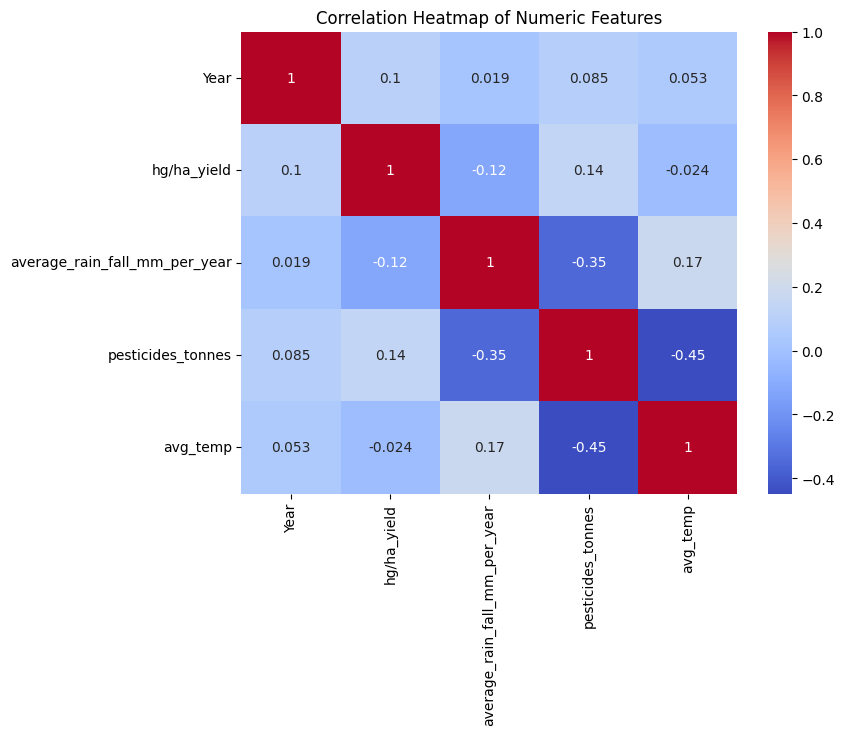

In [10]:
plt.figure(figsize=(8,6))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

### Correlation Heatmap Interpretation
None of the numeric features correlate strongly with yield on their own — pesticides (0.14) and
Year (0.10) show weak positive correlation, rainfall is weakly negative (-0.12), and temperature
is nearly flat (-0.02). This suggests yield isn't driven by any single factor in isolation, but by
interactions between features (e.g. rainfall combined with crop type or region) and by the
categorical features (Area, Item) not shown here. This weak linear relationship hints that a linear
model won't capture much — confirmed later when Random Forest (R² = 0.96) far outperformed Linear
Regression (R² = 0.65).

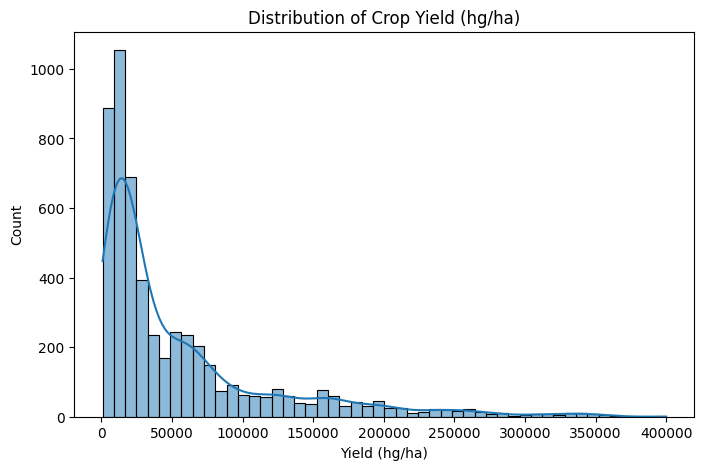

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(df['hg/ha_yield'], bins=50, kde=True)
plt.title('Distribution of Crop Yield (hg/ha)')
plt.xlabel('Yield (hg/ha)')
plt.show()

### Yield Distribution Interpretation
The yield distribution is heavily skewed to the right — most crops/countries produce yields under
100,000 hg/ha, with the biggest cluster sitting around 20,000-30,000, but there's a long tail
stretching all the way to 500,000.

So a smaller number of cases are pulling in really high yields, while most of the data sits much
lower. This matters for a couple of reasons: it means a few high-yield outliers could skew error
metrics like MSE, and it's another reason tree-based models made sense here — they can split the
data by crop or region and handle these high-yield cases separately, instead of assuming one
straight-line relationship applies to everything.

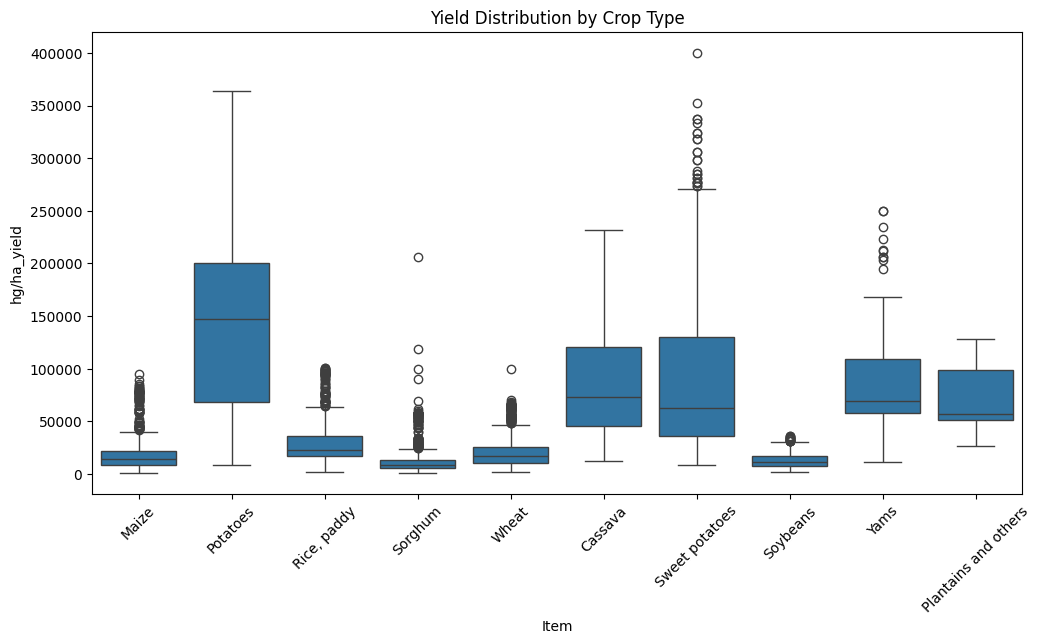

In [12]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df, x='Item', y='hg/ha_yield')
plt.xticks(rotation=45)
plt.title('Yield Distribution by Crop Type')
plt.show()

### Yield Distribution by Crop Type Interpretation
Yield varies a lot by crop: Potatoes lead by far (median approx. 147,000 hg/ha), followed by Cassava,
Yams, and Sweet potatoes (approx. 60,000-75,000), while Sorghum, Soybeans, and Maize sit much lower
(approx. 8,000-14,000). This confirms crop type strongly affects yield, justifying one-hot encoding Item
rather than dropping it.

In [13]:
df_encoded = pd.get_dummies(df, columns=['Area', 'Item'], drop_first=True)
df_encoded.head()

,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp,Area_Angola,Area_Botswana,Area_Burkina Faso,Area_Burundi,Area_Cameroon,...,Area_Zimbabwe,Item_Maize,Item_Plantains and others,Item_Potatoes,"Item_Rice, paddy",Item_Sorghum,Item_Soybeans,Item_Sweet potatoes,Item_Wheat,Item_Yams
99,1990,16500,89.0,1828.92,17.48,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
100,1990,78936,89.0,1828.92,17.48,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
101,1990,28000,89.0,1828.92,17.48,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
102,1990,16571,89.0,1828.92,17.48,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
103,1990,6315,89.0,1828.92,17.48,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False


### Feature Engineering Interpretation
Area (country) and Item (crop type) were both text/categorical columns, so they needed to be
converted to numeric using one-hot encoding before the model could use them. Based on the boxplot
above, Item clearly matters a lot — different crops have very different yield ranges — so this was
an important feature to keep and encode properly, not drop.

Year was kept as a numeric feature but didn't show strong correlation with yield on its own, so its
predictive value likely comes more from interacting with other features (e.g. farming practices
improving over time) rather than acting as a strong standalone predictor.

In [14]:
X = df_encoded.drop(columns=['hg/ha_yield'])
y = df_encoded['hg/ha_yield']

print(X.shape, y.shape)

(5362, 43) (5362,)


In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)

(4289, 43) (1073, 43)


In [16]:
from sklearn.preprocessing import StandardScaler

numeric_cols = ['Year', 'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp']

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

X_train_scaled.head()

,Year,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp,Area_Angola,Area_Botswana,Area_Burkina Faso,Area_Burundi,Area_Cameroon,Area_Central African Republic,...,Area_Zimbabwe,Item_Maize,Item_Plantains and others,Item_Potatoes,"Item_Rice, paddy",Item_Sorghum,Item_Soybeans,Item_Sweet potatoes,Item_Wheat,Item_Yams
8252,0.050996,-1.386043,0.163083,0.035678,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
24040,-0.232138,0.817869,-0.526236,-0.692249,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
27320,1.041966,0.757124,-0.534370,0.492568,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
219,-1.506243,0.434415,-0.535611,0.451267,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
18349,0.617265,0.759022,-0.518605,-0.423794,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [17]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

lr_pred = lr_model.predict(X_test_scaled)

lr_mse = mean_squared_error(y_test, lr_pred)
lr_r2 = r2_score(y_test, lr_pred)

print("Linear Regression - MSE:", lr_mse, "R2:", lr_r2)

Linear Regression - MSE: 1592791936.6044385 R2: 0.6467676138436788


In [18]:
from sklearn.linear_model import SGDRegressor

sgd_model = SGDRegressor(max_iter=1000, learning_rate='invscaling', eta0=0.01, random_state=42)
sgd_model.fit(X_train_scaled, y_train)

sgd_pred = sgd_model.predict(X_test_scaled)

sgd_mse = mean_squared_error(y_test, sgd_pred)
sgd_r2 = r2_score(y_test, sgd_pred)

print("SGD Regressor - MSE:", sgd_mse, "R2:", sgd_r2)

SGD Regressor - MSE: 1607969874.2275772 R2: 0.6434016129239462


In [19]:
from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train_scaled, y_train)

dt_pred = dt_model.predict(X_test_scaled)

dt_mse = mean_squared_error(y_test, dt_pred)
dt_r2 = r2_score(y_test, dt_pred)

print("Decision Tree - MSE:", dt_mse, "R2:", dt_r2)

Decision Tree - MSE: 238796625.4967381 R2: 0.947042234524296


In [20]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

rf_pred = rf_model.predict(X_test_scaled)

rf_mse = mean_squared_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest - MSE:", rf_mse, "R2:", rf_r2)

Random Forest - MSE: 194030661.1839438 R2: 0.9569699520305179


### Model Comparison Interpretation
Random Forest performed best (R² = 0.957, MSE ≈ 194M), followed closely by Decision Tree
(R² = 0.947). Both far outperformed Linear Regression and SGD Regressor (R² ≈ 0.64-0.65),
confirming that yield depends on non-linear interactions between rainfall, temperature, and crop
type rather than any single linear relationship. Random Forest was selected as the final model
based on its lowest MSE and highest R² on the test set.

In [21]:
import joblib

joblib.dump(rf_model, 'best_model.pkl', compress=3)
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(X.columns.tolist(), 'feature_columns.pkl')
print("Model, scaler, and feature columns saved successfully")

Model, scaler, and feature columns saved successfully


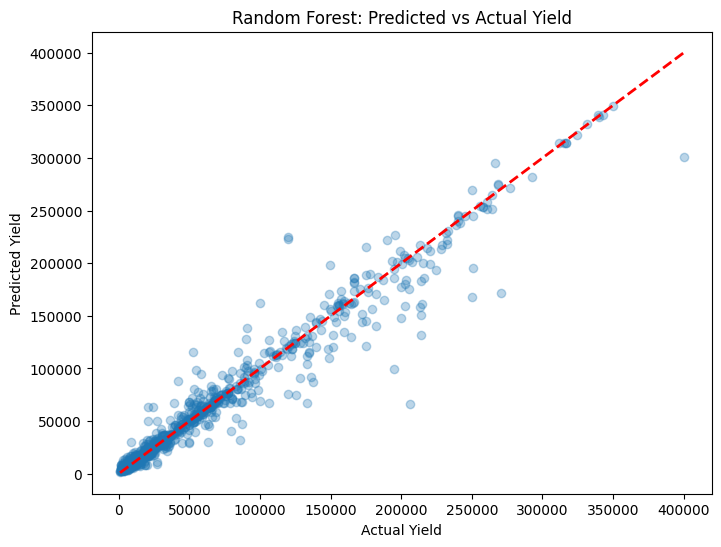

In [22]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, rf_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Yield')
plt.ylabel('Predicted Yield')
plt.title('Random Forest: Predicted vs Actual Yield')
plt.show()

### Predicted vs Actual Yield Interpretation
Points cluster tightly along the diagonal red line, especially at lower yield values, confirming
the model's strong accuracy. Some spread appears at higher yields, suggesting slightly more error
on high-yield outliers — consistent with the right-skewed distribution seen earlier.

In [23]:
sample = X_test_scaled.iloc[[0]]
actual_value = y_test.iloc[0]
predicted_value = rf_model.predict(sample)[0]

print("Actual yield:", actual_value)
print("Predicted yield:", predicted_value)

Actual yield: 53989
Predicted yield: 55376.41


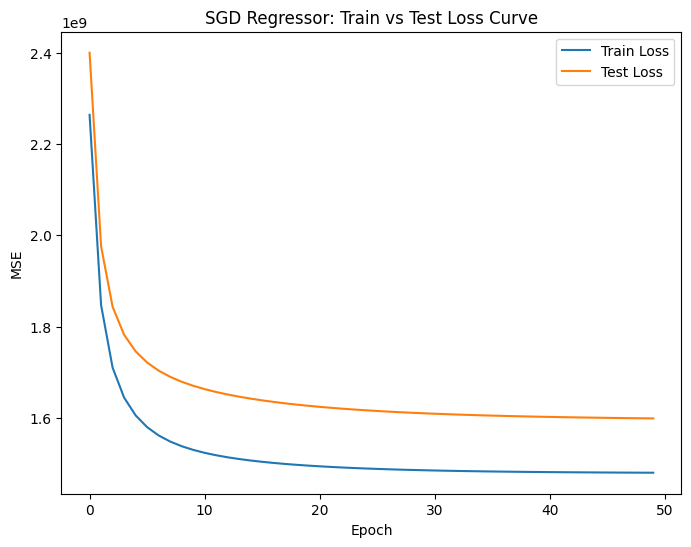

In [24]:
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings('ignore', category=ConvergenceWarning)

from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error

n_epochs = 50
train_errors = []
test_errors = []

sgd = SGDRegressor(max_iter=1, learning_rate='invscaling', eta0=0.01, warm_start=True, random_state=42)

for epoch in range(n_epochs):
    sgd.fit(X_train_scaled, y_train)
    train_pred = sgd.predict(X_train_scaled)
    test_pred = sgd.predict(X_test_scaled)
    train_errors.append(mean_squared_error(y_train, train_pred))
    test_errors.append(mean_squared_error(y_test, test_pred))

plt.figure(figsize=(8,6))
plt.plot(range(n_epochs), train_errors, label='Train Loss')
plt.plot(range(n_epochs), test_errors, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.title('SGD Regressor: Train vs Test Loss Curve')
plt.legend()
plt.show()

### Loss Curve Interpretation
Train and test loss track closely together and drop sharply in the first ~15 epochs before
flattening out, showing the model is learning steadily without overfitting. However, the loss
plateaus at a much higher level than the tree-based models achieved, reinforcing that SGD's linear
approach can't fully capture the non-linear patterns in this dataset.

In [25]:
def predict_yield(area, item, year, rainfall, pesticides, avg_temp):
    # Build a single-row dict with all base numeric features
    row = {
        'Year': year,
        'average_rain_fall_mm_per_year': rainfall,
        'pesticides_tonnes': pesticides,
        'avg_temp': avg_temp
    }

    # Add one-hot columns, all 0 by default
    for col in X.columns:
        if col.startswith('Area_') or col.startswith('Item_'):
            row[col] = 0

    # Build dataframe in one go (fixes fragmentation warning)
    input_df = pd.DataFrame([row])

    # Set the correct Area/Item column to 1
    if f'Area_{area}' in input_df.columns:
        input_df[f'Area_{area}'] = 1
    if f'Item_{item}' in input_df.columns:
        input_df[f'Item_{item}'] = 1

    # Reorder columns to match training data exactly
    input_df = input_df.reindex(columns=X.columns, fill_value=0)

    # Scale numeric columns
    input_df[numeric_cols] = scaler.transform(input_df[numeric_cols])

    prediction = rf_model.predict(input_df)
    return prediction[0]

# Test it
test_prediction = predict_yield('Albania', 'Maize', 2013, 1500, 130, 16.5)
print("Predicted yield:", test_prediction)

Predicted yield: 14656.84
